# **Exploratory Data Analysis for Products and Sellers**
#### Finding Patterns in Products & Sellers **fix this when finished*

## Table of Contents

- [0. EDA for Products & Sellers Summary](#topic-0)
- [1. Import Libraries](#topic-1)
- [2. Import Data](#topic-2)
- [3. Analysis Section](#topic-3)
  - [3.1 ](#topic-3-1)
  - [3.2 ](#topic-3-2)
  - [3.3 ](#topic-3-3)
  - [3.4 ](#topic-3-4)
  - [3.5 ](#topic-3-5)
- [4. Conclusion & Insights Recap](#topic-4)
- [5. Recommendations based on Insights](#topic-5)


## **0. EDA for Products & Sellers Summary** <a id="topic-0"></a>

- texts

## **1. Import Libraries** <a id="topic-1"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## **2. Import Data** <a id="topic-2"></a>

In [2]:
date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_timestamp", "order_estimated_delivery_date"]

orders = pd.read_csv('../data/processed/orders.csv')
orders[date_cols] = orders[date_cols].apply(pd.to_datetime, errors='coerce')  # Safely parse all, fallback if weird values

orders["delivery_time_gap"] = pd.to_timedelta(orders["delivery_time_gap"], errors='coerce')

order_items = pd.read_csv('../data/processed/order_items.csv')
customers = pd.read_csv('../data/processed/customers.csv')
payments = pd.read_csv('../data/processed/payments.csv')
products = pd.read_csv('../data/processed/products.csv')

## **3. Analysis Section** <a id="topic-3"></a>
***alter with corresponding text when done***
- Data Exploration: This section dives deep into customer behavior, order performance, regional trends, and delivery dynamics statistical & visualization methods.
- Visual-Driven: Data is visualized through a variety of plots — bar plots, histograms, KDEs, line graphs — to surface hidden patterns and outliers.
- Contextual Commentary: Every insight is paired with interpretation to understand its potential business or logistic impact.
- Subsection-Focused: The section is divided into specific focus areas like Order Status, Delivery Timings, Monthly Trends, and Regional Insights.
- Real-World Takeaways: Each analysis aims to bring forward operational or strategic implications, making the data actionable.

In [3]:
#### Data Overview
products.head()

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,weight_volume_ratio
0,90K0C1fIyQUf,toys,491.0,19.0,12.0,16.0,3648.0,0.134594
1,qejhpMGGVcsl,watches_gifts,440.0,18.0,14.0,17.0,4284.0,0.102708
2,qUS5d2pEAyxJ,costruction_tools_garden,2200.0,16.0,16.0,16.0,4096.0,0.537109
3,639iGvMyv0De,toys,1450.0,68.0,3.0,48.0,9792.0,0.148080
4,1lycYGcsic2F,toys,300.0,17.0,4.0,12.0,816.0,0.367647


In [4]:
order_items.head()

,order_id,product_id,seller_id,price,shipping_charges,shipping_price_ratio
0,Axfy13Hk4PIk,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,0.378730
1,v6px92oS8cLG,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,0.139286
2,Ulpf9skrhjfm,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,0.269876
3,bwJVWupf2keN,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,0.116144
4,Dd0QnrMk9Cj5,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,0.039313


In [5]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_diff
0,Axfy13Hk4PIk,1,credit_card,1,259.14,49.02
1,v6px92oS8cLG,1,credit_card,8,382.39,-187.80
2,Ulpf9skrhjfm,1,credit_card,4,249.25,-167.47
3,bwJVWupf2keN,1,credit_card,2,27.79,267.43
4,Dd0QnrMk9Cj5,1,credit_card,1,76.15,734.41


In [6]:
customers.head()

,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,hCT0x9JiGXBQ,58125,varzea paulista,SP
1,PxA7fv9spyhx,3112,armacao dos buzios,RJ
2,g3nXeJkGI0Qw,4119,jandira,SP
3,EOEsCQ6QlpIg,18212,uberlandia,MG
4,mVz5LO2Vd6cL,88868,ilhabela,SP


#### **3.1 Product Category Distribution** <a id="topic-3-1"></a>

***stuff about it***

In [7]:
len(products)

26344

In [8]:
product_categories_counts = products['product_category_name'].value_counts()
product_categories_counts

product_category_name
toys                                 19890
bed_bath_table                         629
sports_leisure                         610
furniture_decor                        534
health_beauty                          513
                                     ...  
flowers                                  2
home_comfort_2                           1
furniture_mattress_and_upholstery        1
fashion_childrens_clothes                1
security_and_services                    1
Name: count, Length: 69, dtype: int64

**This shows that:**
- Toys are most prominent category among all 26344 products, 19890 (about 75.5%) products are toys.
- And this is over 30 times the product category which is second to it.
- While some categories exist with only a few products (as few as 1).

In [9]:
len(product_categories_counts[product_categories_counts.values < 50])

44

**This shows that:**
- More than half (44, total categories = 69) of the product categories have less than 50 products.
- We will try to plot these separately, and higher ones separately. And probably try to not include the toys category as it diminishes the rest of the data.

#### Bar Plots for Top & Bottom Product Categories 
- points
- another

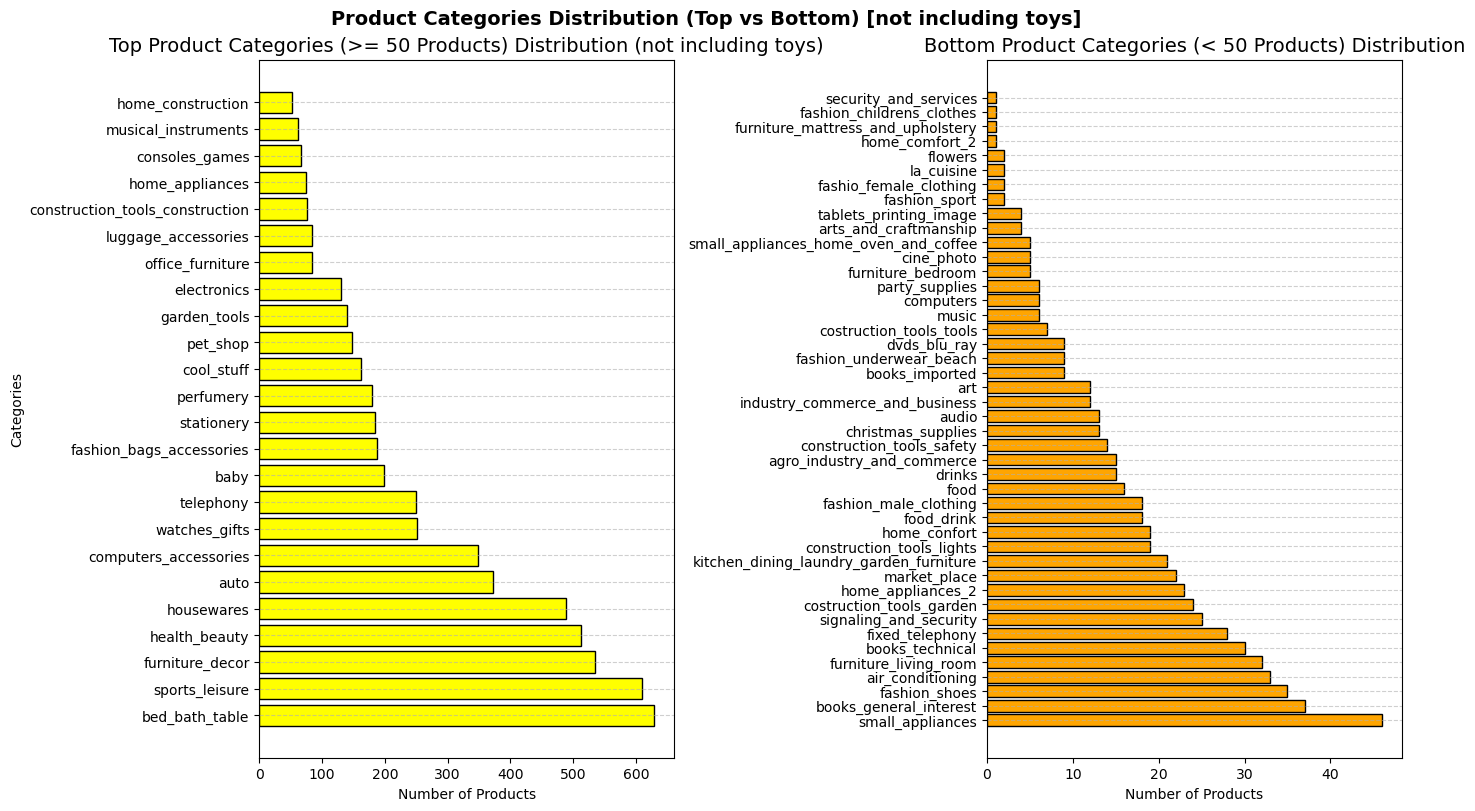

In [10]:
top_categories = product_categories_counts[product_categories_counts.between(50, 1000)] # not including toys
bottom_categories = product_categories_counts[product_categories_counts < 50] # categories with less than 50 products.
fig, axes = plt.subplots(1, 2, figsize=(14, 8), constrained_layout=True)

# Bar Plot for top categories
axes[0].barh(top_categories.index, top_categories.values, color='yellow', edgecolor='black')
axes[0].set_title("Top Product Categories (>= 50 Products) Distribution (not including toys)", fontsize=14)
axes[0].set_ylabel("Categories")
axes[0].set_xlabel("Number of Products")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# bar plot for bottom categories
axes[1].barh(bottom_categories.index, bottom_categories.values, color='orange', edgecolor='black')
axes[1].set_title("Bottom Product Categories (< 50 Products) Distribution", fontsize=14)
axes[1].set_xlabel("Number of Products")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle("Product Categories Distribution (Top vs Bottom) [not including toys]", fontsize=14, fontweight='bold')
plt.show()

**This implies that:**
- Maximum number of product categories have less than a 100 products.
- Many bottom categories with low number of products can be combined to create a single category such as fashion and furniture, as there are many sub-categories of these categories with small number of products.

---
#### **3.2 Product Weight & Volume Analysis** <a id="topic-3-2"></a>
- point 1
- point 2

In [11]:
products.describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,weight_volume_ratio
count,26344.000000,26344.000000,26344.000000,26344.000000,26344.000000,26344.000000
mean,2254.583055,30.670855,16.880390,23.110955,16361.967507,0.203561
std,4227.208850,16.767689,13.632374,11.973130,26678.952261,0.979014
min,2.000000,7.000000,2.000000,6.000000,168.000000,0.000220
25%,300.000000,18.000000,8.000000,15.000000,2860.000000,0.066667
50%,700.000000,25.000000,13.000000,20.000000,6732.000000,0.116550
75%,1850.000000,38.000000,20.000000,30.000000,18032.000000,0.195312
max,40425.000000,105.000000,105.000000,118.000000,294000.000000,65.909091


**This implies that:**
- Average weight and volume of a product is 2254 grams & 19362 cm^3 (approx.)
- And from the quartile values we can understand that 75% of the products weigh less than 1.85 kg & volume less than 18032 cm^3. This suggests that most of the products are lighter than 2 kgs while some products have very high weight that goes upto 40 kgs.
- Similarly for volume: Generally volume is less than 18032 cm^3 or 18 L. (approx.) while some go upto 294 L.
---

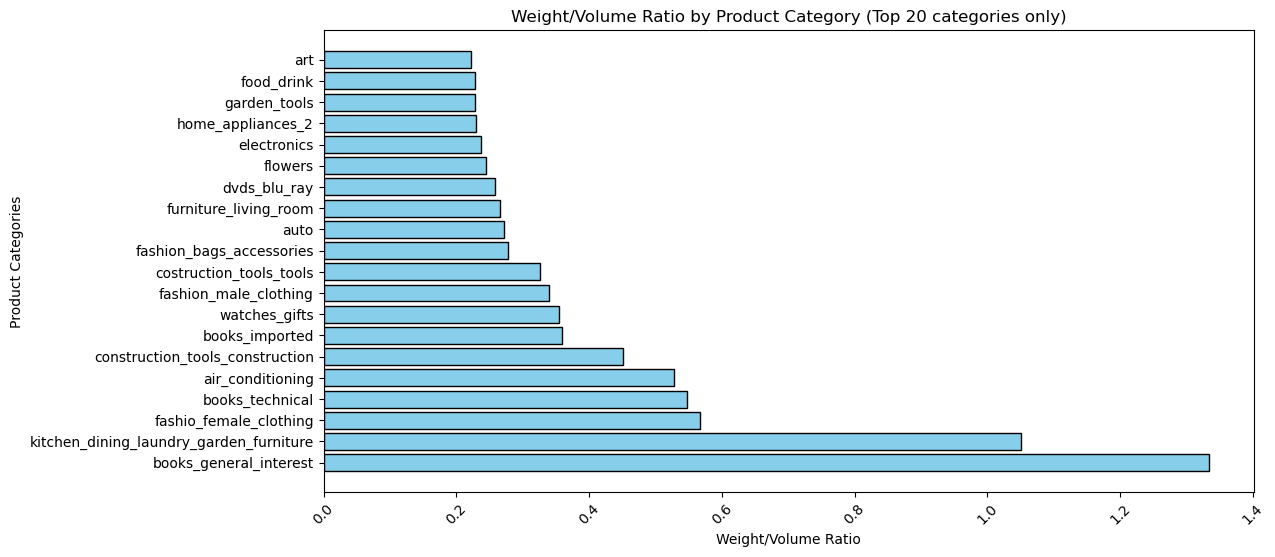

In [12]:
weight_volume_by_category = products.groupby('product_category_name')[['product_weight_g', 'product_volume_cm3', 'weight_volume_ratio']].mean().sort_values(by='weight_volume_ratio', ascending=False)
plt.figure(figsize=(12,6))
plt.barh(weight_volume_by_category.head(20).index, weight_volume_by_category['weight_volume_ratio'].head(20), color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Weight/Volume Ratio')
plt.ylabel('Product Categories')
plt.title('Weight/Volume Ratio by Product Category (Top 20 categories only)')
plt.show()

**This implies that:**
- Books, in general, have around 0.9 to 1.5 g/cm3 weight/volume ratio, this high value(approx 1.35) for this ratio signifies that most books must be hardcover or coffee table books as they have higher weight/volume ratio compared to paperback.
- The second highest weight/volume ratio is for furniture for kitchen/dining/garden, this is expected to have high weight volume ratio as they include smaller pieces of furniture (leading to low volume), resulting in high w/v ratio.
- Most of the product categories have weight/volume ratio < 0.2, which means that most categories weigh very less compared to their size. Thus, for these categories delivery services and logistics with more volume capacity is needed while weight taking capacity can be lower, as volume is a bigger factor here, compared to weight.
---

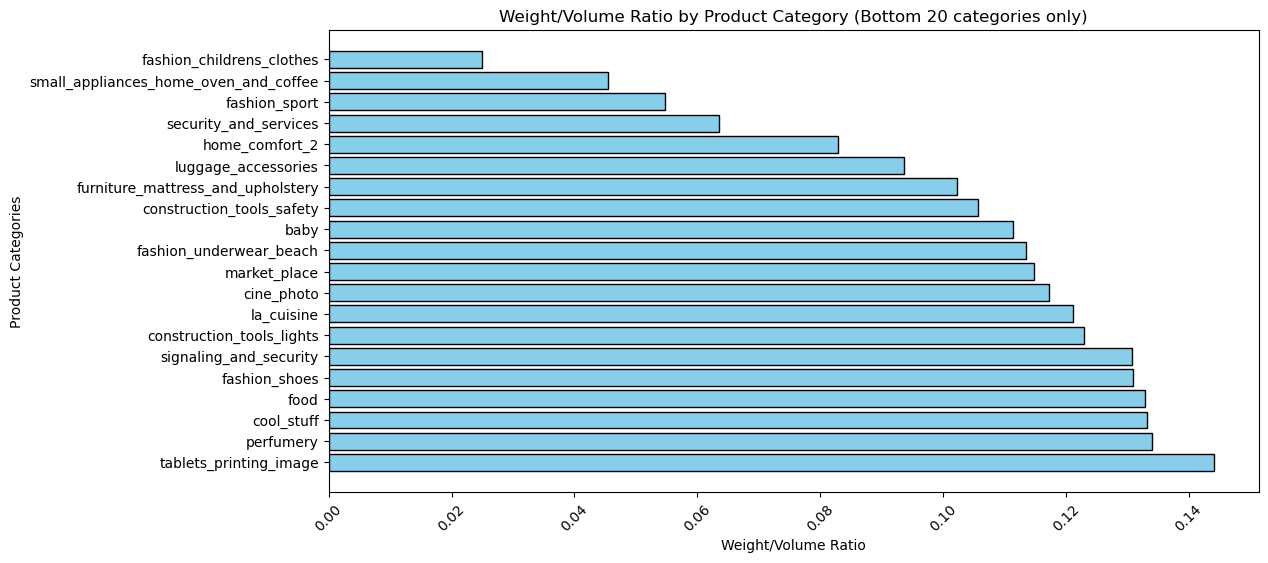

In [13]:
plt.figure(figsize=(12,6))
plt.barh(weight_volume_by_category.tail(20).index, weight_volume_by_category['weight_volume_ratio'].tail(20), color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Weight/Volume Ratio')
plt.ylabel('Product Categories')
plt.title('Weight/Volume Ratio by Product Category (Bottom 20 categories only)')
plt.show()

**This implies that:**
- Most of the categories in the bottom 20 categories are generally light, leading to low weight and less weight/volume ratio, hence these categories have low weight/volume ratio.
- This may also be due to large volume compared to size, like the category furniture_mattress_upholstery (includes mattresses & upholstery) which are generally large in volume but very light due to the material they are made of.
---

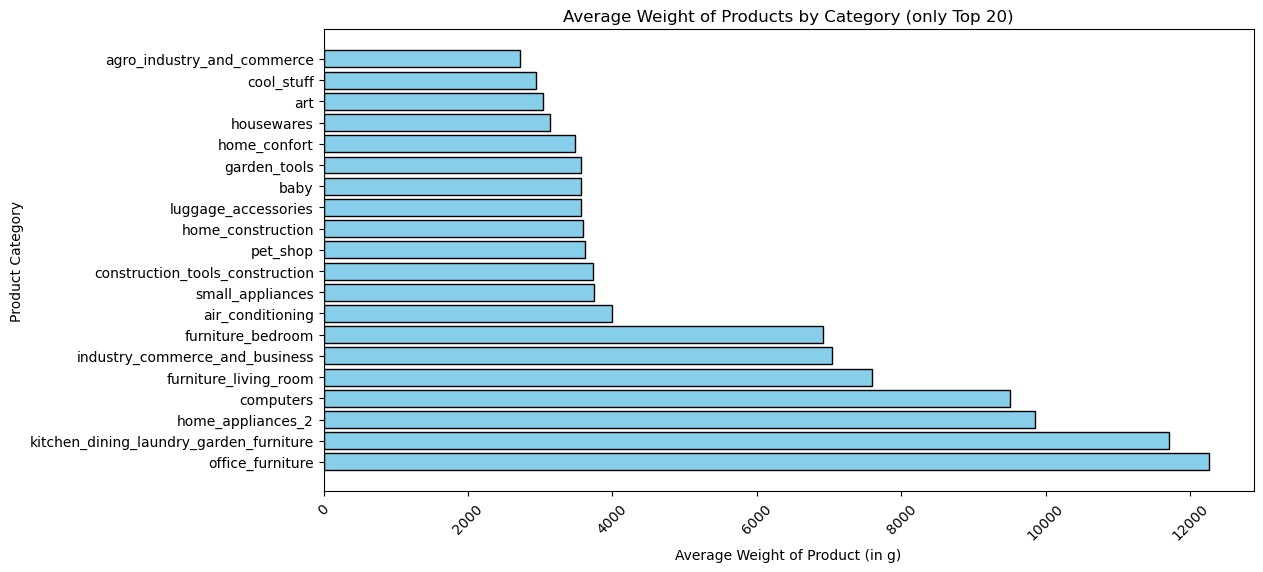

In [14]:
weight_volume_by_category = weight_volume_by_category.sort_values(by='product_weight_g', ascending=False)
plt.figure(figsize=(12,6))
plt.barh(weight_volume_by_category.head(20).index, weight_volume_by_category['product_weight_g'].head(20), color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Average Weight of Product (in g)')
plt.ylabel('Product Category')
plt.title('Average Weight of Products by Category (only Top 20)')
plt.show()

**This implies that:**
- Most of these categories are supposed to have high average weight like furniture and appliances. Hence it fits well with this plot.
- Furniture, appliances and tools have high weight on average as expected from categories like this.
- Baby products, art & cool_stuff categories have average weight of about 2-3 kg (2000-3000 g), implying mostly for these products large variants/versions of the products are preferred, which may lead to high weight.
---

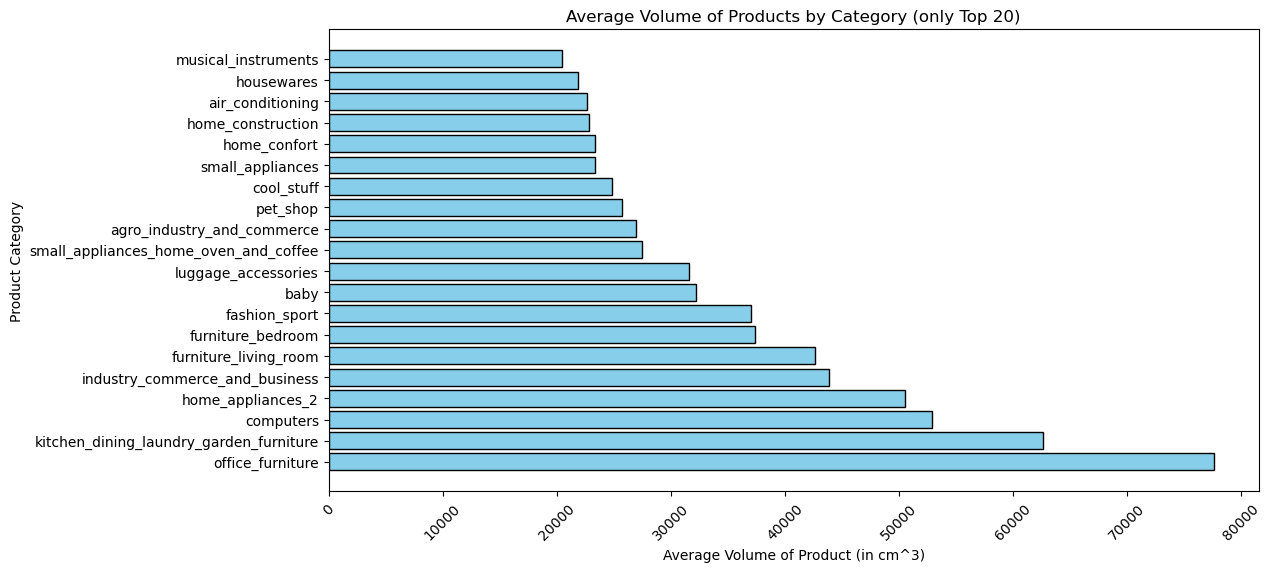

In [15]:
weight_volume_by_category = weight_volume_by_category.sort_values(by='product_volume_cm3', ascending=False)
plt.figure(figsize=(12,6))
plt.barh(weight_volume_by_category.head(20).index, weight_volume_by_category['product_volume_cm3'].head(20), color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Average Volume of Product (in cm^3)')
plt.ylabel('Product Category')
plt.title('Average Volume of Products by Category (only Top 20)')
plt.show()

**This implies that:**
- The top categories by volume are mainly furniture, appliances and computers. This suggests that these categories have bulkier/larger, high value products. Thus, in the storage and logistics of these products, their high volume and costs should be prioritized.
- Baby and Pet shop products also have high volume too (they had high weight as well as observed in previous plot), reinforcing the idea that larger variants (or bundles) of these products are preferred by the customers.
- The category fashion_sport also has an unusually high volume, which may be due to the oversized & premium packaging of sports & athleisure wear. Or it may be due to customer preference of bulkier clothing types, like jackets/tracksuits.

---
#### **3.3 Seller Order Distribution** <a id="topic-3-3"></a>

In [16]:
order_items_by_seller = order_items.groupby('seller_id')[['price', 'shipping_charges', 'shipping_price_ratio']].mean()

In [17]:
order_items_by_seller.describe()

,price,shipping_charges,shipping_price_ratio
count,2872.000000,2872.000000,2872.000000
mean,280.564568,43.302940,0.524350
std,255.053033,21.600200,0.513487
min,0.850000,0.320000,0.001700
25%,124.862222,31.510865,0.214061
50%,217.176802,40.844591,0.400015
75%,349.922515,51.020556,0.646438
max,2899.000000,339.590000,4.682292


In [18]:
order_items_by_seller.head()

,price,shipping_charges,shipping_price_ratio
seller_id,,,
00IDBo9tDI9Z,167.840000,28.225000,0.168166
00U0Udw6rshU,148.924737,41.003684,0.697158
01xUkncqaD55,182.900000,55.540000,0.303663
03T0IIjAYOer,46.600000,7.520000,0.161373
03udyaVfPg3w,327.108571,62.440000,0.845398


In [23]:
seller_order_counts = order_items.groupby('seller_id')[['order_id']].nunique()
seller_order_counts.columns = ['num_of_orders'] #giving number of orders per seller column name

In [25]:
seller_order_counts.describe()

,num_of_orders
count,2872.000000
mean,29.387883
std,90.757457
min,1.000000
25%,2.000000
50%,6.000000
75%,21.000000
max,1546.000000


**This implies that:**
- From the quartile values we get that, 75% of the sellers handle less than 21 orders.
- 75% of sellers get less than 21 orders, indicating a large number of small or individual sellers that contribute marginally to the platform.
- The max order count of 1546 for a single seller, shows a large right-skew in number of orders per seller, suggesting that some high-performing sellers are dominating, this is most likely due to brands or large-scale sellers.
- 25% of sellers get only 2 or less orders, indicate that a significant portion may be occasional or new sellers with limited traction & reach.
- While, the median number of orders is 6, the mean/average number of orders is 29-30 again reinforcing the fact that large-scale sellers dominate tha market.

In [46]:
len(seller_order_counts[seller_order_counts['num_of_orders'] >= 100])

177

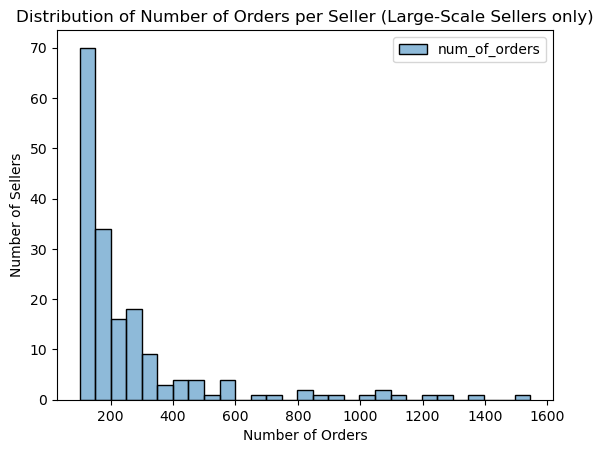

In [56]:
sns.histplot(seller_order_counts[seller_order_counts['num_of_orders'] >= 100], binwidth=50)
plt.title('Distribution of Number of Orders per Seller (Large-Scale Sellers only)')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Sellers')
plt.show()

**This plot implies that:**
- (Large-scale sellers here refer to sellers with over 100 orders.)
- There are only 177 large-scale sellers out of the 2872 of total sellers (approx. 6.2 %), that recieved over 100 orders. This tells us that consistent high number of orders are quite rare and competetive.
- Only 15 sellers recieved over 500 orders, while only 8 sellers go over 1000 orders. Indicating that a small percentage of sellers dominate the market.
- From this we can understand that platform's logistics, buyer experience and revenue may be highly dependent on some elite sellers.

#### Sellers Per Product/Product per Seller

In [104]:
product_per_seller = order_items.groupby('seller_id')['product_id'].nunique().reset_index()
product_per_seller.rename(columns={'product_id':'unique_products'}, inplace=True)

In [105]:
product_per_seller.describe()

,unique_products
count,2872.000000
mean,9.558844
std,20.336323
min,1.000000
25%,1.000000
50%,3.000000
75%,9.000000
max,324.000000


In [106]:
len(product_per_seller[product_per_seller['unique_products'] >= 50])

96

In [107]:
len(product_per_seller[product_per_seller['unique_products'] >= 100])

33

**This implies that:**
- 75% of the sellers, sell less than 9 unique products. This shows that the small scale, individual sellers generally sell niche and specific products on the platform.
- While 96 sellers do sell over 50 unique products, indicating that the large scale sellers, tend to have a wide variety of products, leading to their high order volumes.
- Also some dominant sellers have over 100 unique products to sell, leading to their enormous order volume.

In [108]:
seller_per_product = order_items.groupby('product_id')[['seller_id']].nunique().reset_index()
seller_per_product.rename(columns={'seller_id': 'unique_sellers'}, inplace=True)

In [109]:
seller_per_product.describe()

,unique_sellers
count,26344.000000
mean,1.042097
std,0.251051
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,8.000000


In [128]:
len(seller_per_product[seller_per_product['unique_sellers'] == 1])

25431

In [129]:
len(seller_per_product[seller_per_product['unique_sellers'] >= 2])

913

In [126]:
len(seller_per_product[seller_per_product['unique_sellers'] >= 5])

13

**This implies that:**
- From the quartiles value we get that most of the products are sold by a single unique seller. In fact, 25431 products (96.5%) are sold by a unique single seller. This again reaffirms the insight we obtained from previous analysis, that the small, individual sellers are niche and sell a specific and unique products.
- Also, only a small percentage (~3.5%) products are being sold by multiple sellers. While only 13 products are sold by over 5 unique sellers, reaffriming the previous claim.
- Just 913 products are sold by more than 5 sellers, indicating that only some products have high commercial demand or are common products.
- This low number of overlapping products reduces competition for the sellers, but also limits the customer's choice for a certain product, hence comparative shopping would be reduced.

---
#### **3.4 Top Sellers by Volume/Revenue** <a id="topic-3-4"></a>

In [157]:
order_items['total_revenue'] = order_items['price'] + order_items['shipping_charges']

In [146]:
seller_stats = order_items.groupby('seller_id').agg({'order_id': 'count', 'total_revenue': 'sum' }).rename(columns={'order_id': 'items_sold'})
top_sellers_by_orders = seller_stats.sort_values(by='items_sold', ascending=False).head(10)
top_sellers_by_revenue = seller_stats.sort_values(by='total_revenue', ascending=False).head(10)

In [158]:
order_items['total_revenue'].sum()

28525678.66

##### Printing the seller_id's for the sellers that are in both top 10 in volume & revenue

In [147]:
for i in top_sellers_by_orders.index:
    if (top_sellers_by_revenue.index == i).sum():
        print(i)

RKad98cTxhSb
ruq0u2ZpAMDr
yGbPyLPc8PmT
K0qPVGdA91KO
UOGIrJtSldvd
r7VxefoTVHbb
EGW4UK5bOeEZ
l1pYW6GBnPMr


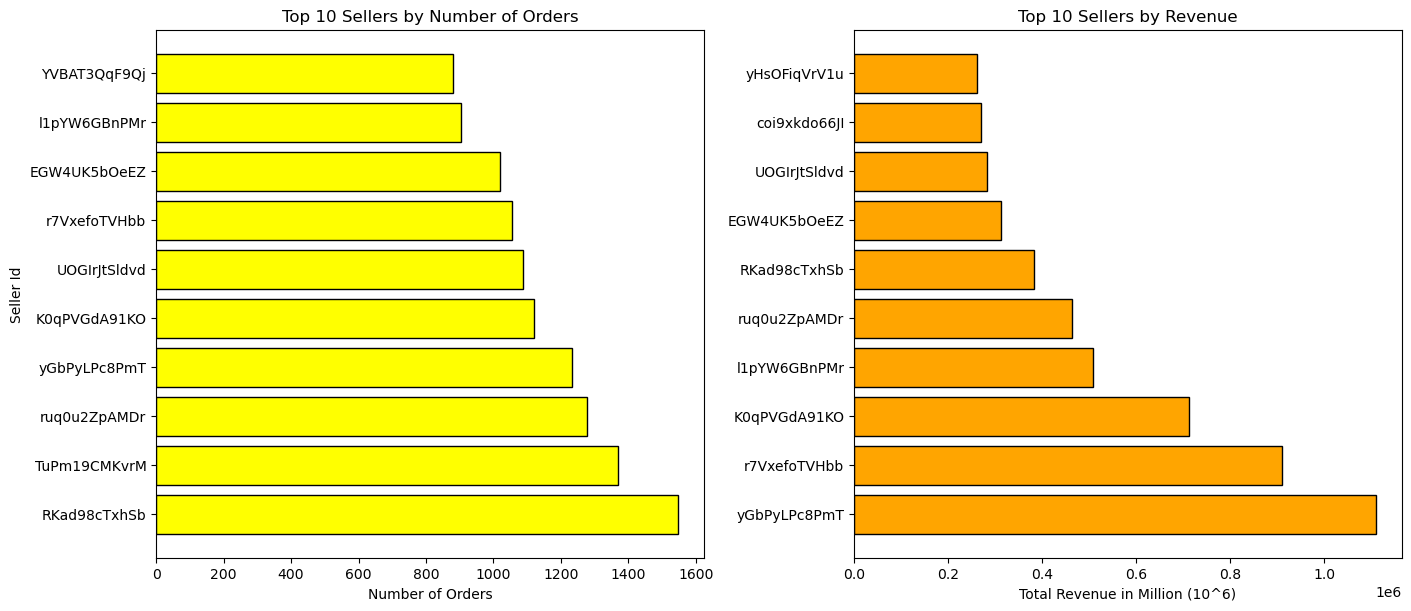

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
axes[0].barh(top_sellers_by_orders.index, top_sellers_by_orders['items_sold'], color='yellow', edgecolor='black')
axes[0].set_title('Top 10 Sellers by Number of Orders')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Seller Id')
axes[1].barh(top_sellers_by_revenue.index, top_sellers_by_revenue['total_revenue'], color='orange', edgecolor='black')
axes[1].set_title('Top 10 Sellers by Revenue')
axes[1].set_xlabel('Total Revenue in Million (10^6)')
plt.show()

**This implies that:**
- In the top 10 sellers by Revenue & Number of Orders, 8 sellers are common, this reaffirms the assumption of large scale sellers dominating the market.
- 

---
#### **3.5 Topic** <a id="topic-3-5"></a>

---
## **4. Conclusion & Insights Recap** <a id="topic-4"></a>

***subtext***

---
## **5. Recommendations based on Insights** <a id="topic-5"></a>
***subtext***